In [1]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from plot_utils import *
import flowi

%matplotlib inline
%load_ext autoreload
%autoreload 2

/Users/rstiskalek/Projects/FlowIntegrator/venv_flowi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


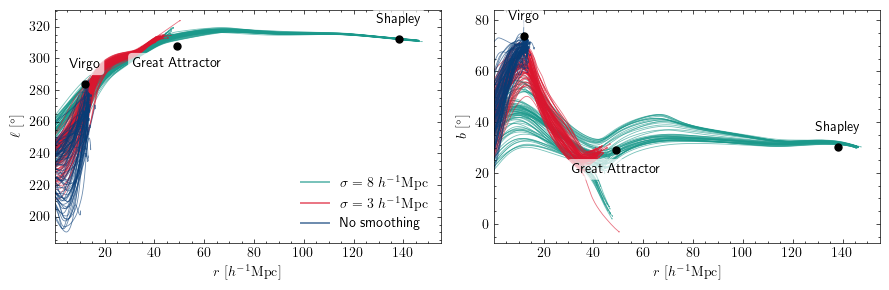

In [16]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/MW_streamlines.hdf5"
smoothing_scales = [0, 3, 8]
downsample = None


fig, axs = plot_mw_streamlines(fname, smoothing_scales, downsample=downsample)

fig.savefig("/Users/rstiskalek/Downloads/mw_streamlines_smoothing.pdf", dpi=300)

display(fig)

$\sigma=2.0\ h^{-1}\ \mathrm{Mpc}$: r = 41 -6.37/+2.01; ell = 313 -7.76/+1.36; b = 27.3 -4.13/+1.4
$\sigma=3.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.3 -4.66/+2.01; ell = 313 -4.76/+1.07; b = 27.4 -4.33/+1.75
$\sigma=4.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.8 -3.47/+1.46; ell = 312 -2.3/+1.25; b = 26.7 -4.56/+2.46


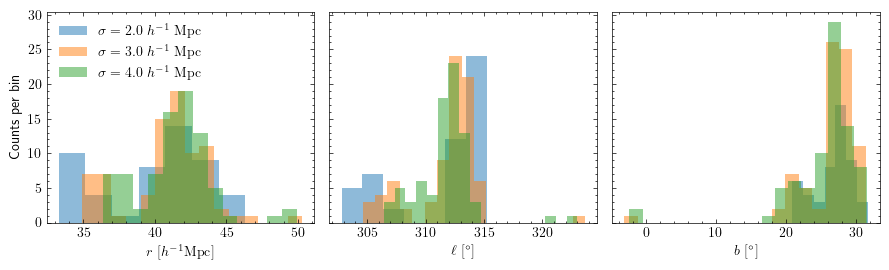

In [116]:
fnames = ["../results/ga_positions_sigma_2.0.txt",
          "../results/ga_positions_sigma_3.0.txt",
          "../results/ga_positions_sigma_4.0.txt",
          ]


# fnames = [f"../results/ga_positions_sigma_{i:.1f}.txt" for i in range(7, 10)]

fig, ax = plot_ga_positions(fnames, 681., r_min=22.5, kde=False)
# fig.savefig("/Users/rstiskalek/Downloads/ga_positions.pdf", dpi=300)
display(fig)

In [ ]:
pos = np.genfromtxt("../results/ga_positions_sigma_3.0.txt")[:, 1:]
center = np.full(3, 681/2)

# pos = flowi.cartesian_icrs_to_galactic_spherical(pos, center)
ga_position = np.array([310.20243187, 327.82457008, 317.06044731])

In [81]:
np.linalg.norm(pos - ga_position, axis=-1)

array([ 5.33395   ,  1.17794072,  3.79476388,  7.47126503,  1.29299525,
        6.70523629,  1.03763381,  2.83538326,  5.39262419,  2.08864863,
        5.69362693,  0.9723521 ,  1.75295011,  1.4442667 ,  1.48744852,
        6.35114544,  1.20871789,  2.50879019,  0.28884094,  4.49567296,
        7.45572499,  2.76345829,  4.3283879 ,  1.73030868,  2.06941702,
        7.59081568,  1.2345752 ,  3.59446047,  1.85123263,  2.4628046 ,
        6.66399576,  1.48902612,  2.2911277 ,  1.63758945,  4.14579574,
        5.79535311,  0.42067316,  3.21527921,  2.05522727,  2.20518778,
        6.07412833,  3.51826162,  3.7986019 ,  1.44147109,  4.25454883,
        6.43392513,  0.8323795 ,  1.14370824,  1.16151649,  3.6635164 ,
        7.44333933,  3.71383853,  2.80358928,  0.43192528,  3.7647016 ,
       26.70253493,  0.59261263,  1.16970946,  2.14707358,  3.36314344,
        7.45345189,  1.52999441,  2.16995169,  0.81260918,  0.65003808,
        7.11798087,  0.6206436 ,  0.89290431,  5.71307247,  1.81

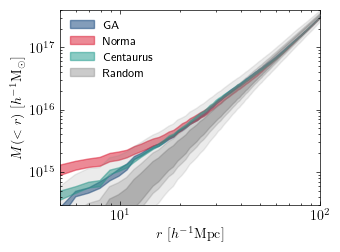

In [106]:
fnames = [
    "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_enclosed_mass.hdf5",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/Norma_enclosed_mass.hdf5",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/Centaurus_enclosed_mass.hdf5",
    ]
labels = ["GA", "Norma", "Centaurus"]

fig, ax = plot_ga_enclosed_mass(fnames, labels=labels)
fig.savefig("/Users/rstiskalek/Downloads/ga_enclosed_mass.pdf", dpi=300, bbox_inches="tight")
display(fig)

In [123]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_analysis.hdf5"

sigma, M = load_ga_metrics(fname, value="ga_mass")
sigma, V = load_ga_metrics(fname, value="ga_volume")

logM = np.log10(M)

R = (V * 3 / (4 * np.pi)) ** (1/3)

In [129]:
sigma

array([ 0.,  2.,  4., 16.])

M [4.0 Mpc/h] = 16.378 (+0.081/-0.037)
R [4.0 Mpc/h] = 42.140 (+3.08/-0.788)


/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_17324/2971711525.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


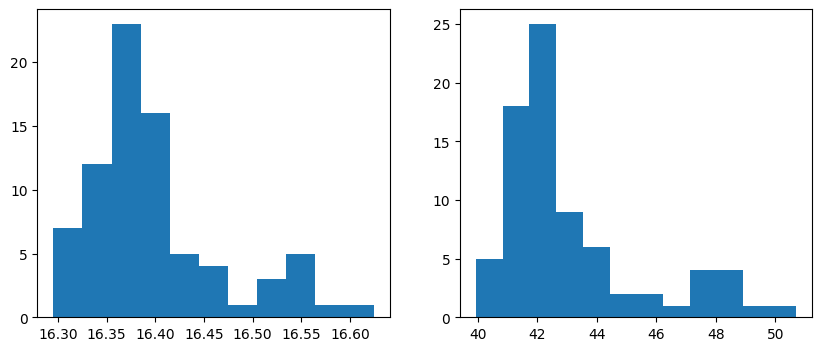

In [131]:
k = 2

print(f"M [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(logM[:, k], 50):.3f} (+{np.nanpercentile(logM[:, k], 84)-np.nanpercentile(logM[:, k], 50):.3f}/-{np.nanpercentile(logM[:, k], 50)-np.nanpercentile(logM[:, k], 16):.3f})")
print(f"R [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(R[:, k], 50):.3f} (+{np.nanpercentile(R[:, k], 84)-np.nanpercentile(R[:, k], 50):.3}/-{np.nanpercentile(R[:, k], 50)-np.nanpercentile(R[:, k], 16):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(np.log10(M[:, k]), bins="auto")
ax[1].hist(R[:, k], bins="auto")

fig.show()


### Virgo position survival

In [ ]:
grp = np.load("/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l150_b-13_d50.npz")
# grp = np.load("/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l302_b32_d34.npz")


logM = np.log10(grp["masses"])
r = grp["distances"]
ell = grp["gal_l"]
b = grp["gal_b"]


# v_ext = np.array([-29.389921, -17.852118, -82.94362], dtype=np.float32)  # km/s, to add to all velocities
# vel = grp["velocities"] + v_ext[np.newaxis, :]
# vel_mag, vel_ell, vel_b = flowi.utils.cartesian_icrs_to_galactic_spherical(vel, center=np.zeros(3))


def asym_err(x):
    p16, p50, p84 = np.nanpercentile(x, [16, 50, 84])
    return p50, p50 - p16, p84 - p50

for name, arr in [("logM", logM), ("r", r), ("ell", ell), ("b", b)]:
    mid, lo, hi = asym_err(arr)
    print(f"{name} = {mid:.3f} -{lo:.3f} +{hi:.3f}")

logM = 14.925 -0.053 +0.089
r = 51.477 -2.170 +1.141
ell = 150.318 -0.370 +0.358
b = -13.454 -0.212 +0.341


/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_64841/1712549853.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


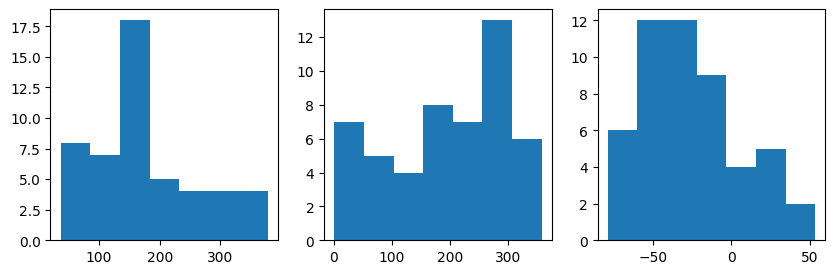

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].hist(vel_mag, bins="auto")
ax[1].hist(vel_ell, bins="auto")
ax[2].hist(vel_b, bins="auto")

fig.show()

In [137]:
np.isfinite(r).sum() / len(r)

np.float64(0.6)

### Virgo movement

In [132]:
def gal_to_cart(r, ell, b):
    """Galactic (deg) + radial distance -> Cartesian xyz."""
    ell_rad = np.deg2rad(ell)
    b_rad = np.deg2rad(b)
    x = r * np.cos(b_rad) * np.cos(ell_rad)
    y = r * np.cos(b_rad) * np.sin(ell_rad)
    z = r * np.sin(b_rad)
    return np.vstack([x, y, z]).T

def cart_to_gal(xyz):
    """Cartesian xyz -> (r, ell_deg, b_deg)."""
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    r = np.sqrt(x**2 + y**2 + z**2)
    ell = np.rad2deg(np.arctan2(y, x)) % 360
    b = np.rad2deg(np.arcsin(z / np.maximum(r, 1e-12)))
    return r, ell, b

def asym_err(x):
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    return p50, p50 - p16, p84 - p50

def compare_snapshots(file_new, file_ref):
    """Load two halo files, compute positional differences in Galactic coords,
    and print asymmetric percentile errors."""
    
    grp_new = np.load(file_new)
    grp_ref = np.load(file_ref)

    # Load quantities
    r1, ell1, b1 = grp_new["distances"], grp_new["gal_l"], grp_new["gal_b"]
    r0, ell0, b0 = grp_ref["distances"], grp_ref["gal_l"], grp_ref["gal_b"]

    # Convert both to Cartesian
    xyz1 = gal_to_cart(r1, ell1, b1)
    xyz0 = gal_to_cart(r0, ell0, b0)

    # Vector differences
    dxyz = xyz1 - xyz0

    # Convert difference vectors back to Galactic coords
    dr, dell, db = cart_to_gal(dxyz)

    # Report asymmetric errors
    for name, arr in [("d_r", dr), ("d_ell", dell), ("d_b", db)]:
        mid, lo, hi = asym_err(arr)
        print(f"{name} = {mid:.3f} -{lo:.3f} +{hi:.3f}")


# Example usage:
compare_snapshots(
    # "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap004_l283_b74_d13.npz",
    # "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l283_b74_d13.npz",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap004_l302_b22_d34.npz",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l302_b22_d34.npz"

)

d_r = 2.218 -0.500 +0.410
d_ell = 25.140 -13.960 +327.303
d_b = 42.743 -15.267 +11.371


In [99]:
r = 34.0
ell = 303.0
b = 21.7


ra, dec = flowi.galactic_to_radec(ell, b)

681 / 2 + gal_to_cart(r, ra, dec)

array([[315.55712222, 334.76738225, 318.1171954 ]])

In [4]:
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306)


a = np.asarray([1, 2, 5, 10])
z = 1 / a - 1

print(a)
print(cosmo.age(z))

[ 1  2  5 10]
[13.76615402 24.7707825  40.41833332 52.35610439] Gyr


In [7]:
data_convergence = load_observer_velocity_convergence("/Users/rstiskalek/Projects/FlowIntegrator/results/linear_velocity_fields.hdf5")


Loading observer velocity convergence from: /Users/rstiskalek/Projects/FlowIntegrator/results/linear_velocity_fields.hdf5
Found 80 fields
Radii: 13 values from 10.0 to 190.0 Mpc/h
Cumulative: True


Loading observer velocities: 100%|██████████| 80/80 [00:00<00:00, 4877.74it/s]


Loaded pre-computed observer velocities: shape (80, 13, 3)
Metadata: Ω_m=0.306, smooth_scale=2.5 Mpc/h, boxsize=681.0 Mpc/h

Extracting observer velocities from full velocity fields...


Extracting full field velocities: 100%|██████████| 80/80 [01:46<00:00,  1.33s/it]


Extracted full field velocities: shape (80, 3)

Converting to Galactic spherical coordinates...

Galactic spherical (full field):
  |v| = 384.2 ± 57.1 km/s
  l   = 234.1 ± 17.3 deg
  b   = 50.9 ± 11.1 deg

Computed statistics over all fields and radii
Data loaded successfully!




Comparison vs CMB-LG dipole

Manticore (obs):
  Magnitude ratio: 0.715 -0.092/+0.094
  Angular offset:  37.51 -9.61/+9.36 deg

Manticore (obs + σ_v=150.0 km/s):
  Magnitude ratio: 0.793 -0.224/+0.232
  Angular offset:  40.54 -16.69/+18.24 deg



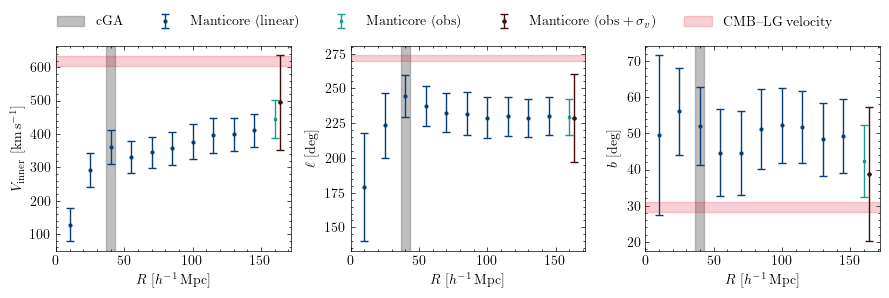

In [47]:
fig, axes = plot_observer_velocity_convergence(data_convergence, output_file=None)
fig.savefig("/Users/rstiskalek/Downloads/manticore_velocity.pdf", dpi=300)
display(fig)

vmag_range = (560, 680) km/s: 1875/15000 (12.5%)
Added 3D velocity uncertainty: σ_v = 150 km/s

At R = 150.0 Mpc/h (No σ_v):
  |v_inner|/|v_box| = 0.937 -0.118/+0.116
  θ = 8.47 -4.25/+5.03 deg

At R = 150.0 Mpc/h (σ_v = 150 km/s):
  |v_inner|/|v_box| = 0.888 -0.180/+0.266
  θ = 18.45 -9.33/+12.45 deg


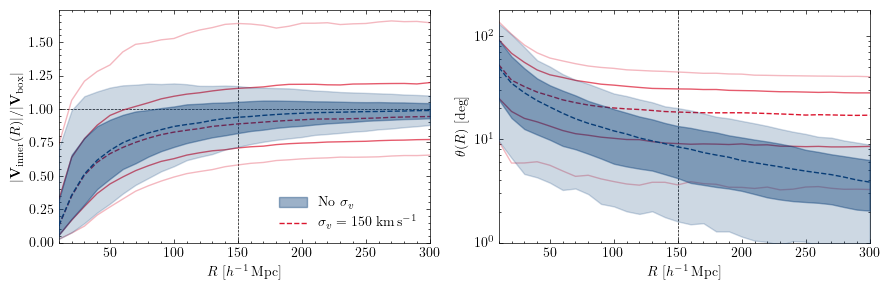

In [48]:
fig, ax = plot_velocity_convergence(
    "/Users/rstiskalek/Projects/FlowIntegrator/results/quijote_fiducial_velocity_convergence_PCS_z0.npz",
    vmag_range=(620 - 4 * 15, 620 + 4 * 15),
    sigma_v=[None, 150],
    theta_ylim=1,
    )

fig.savefig("/Users/rstiskalek/Downloads/velocity_convergence_quijote.pdf", dpi=300)
display(fig)

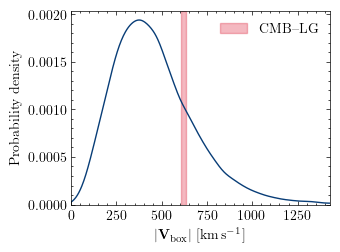

In [49]:
fig, ax = plot_observer_vmag_histogram(
    "/Users/rstiskalek/Projects/FlowIntegrator/results/quijote_fiducial_velocity_convergence_PCS_z0.npz",
    )


fig.savefig("/Users/rstiskalek/Downloads/observer_vmag_histogram_quijote.pdf", dpi=500)
display(fig)


Quijote: vmag_range = (560, 680) km/s: 1875/15000 (12.5%)
Quijote: Using R = 150.0 Mpc/h (requested 150)
Manticore (obs):
  |V| = 443.4 ± 56.8 km/s
  ell = 229.6 ± 13.1 deg
  b   = 42.3 ± 9.9 deg

$\mathrm{No} ~ \sigma_v$
------------------------------------------------------------
Quijote randoms:
  Magnitude ratio: 0.937 ± 0.117
  Angular offset:  8.47 ± 4.82 deg

Manticore:
  Magnitude ratio: 0.716 ± 0.094
  Angular offset:  35.94 ± 11.13 deg

$\sigma_v = 150 ~ \mathrm{km \, s^{-1}}$
------------------------------------------------------------
Quijote randoms:
  Magnitude ratio: 0.888 ± 0.276
  Angular offset:  18.45 ± 10.81 deg

Manticore:
  Magnitude ratio: 0.798 ± 0.230
  Angular offset:  37.03 ± 23.83 deg
$\mathrm{No} ~ \sigma_v$: Posterior agreement = 2.28σ
$\sigma_v = 150 ~ \mathrm{km \, s^{-1}}$: Posterior agreement = 0.39σ


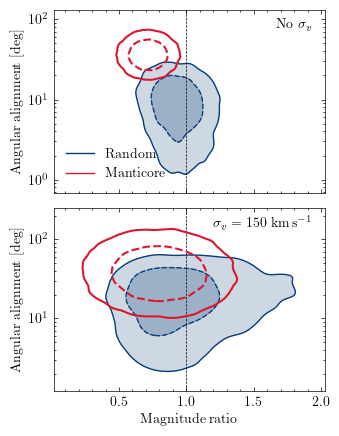

In [50]:
fig, ax = plot_velocity_convergence_scatter(
    "/Users/rstiskalek/Projects/FlowIntegrator/results/quijote_fiducial_velocity_convergence_PCS_z0.npz",
    data_convergence,
    radius=150,
    vmag_range=(620 - 4 * 15, 620 + 4 * 15),
    # vmag_range=(100, 1000),
    # sigma_v=[None, 150],
    sigma_v=[None, 150],
    reference_radius=None,
    gaussianize_manticore=True,)


fig.savefig("/Users/rstiskalek/Downloads/velocity_convergence_significance.pdf", dpi=300)
display(fig)

In [2]:
data_bins = load_observer_velocity_convergence(
    "/Users/rstiskalek/Projects/FlowIntegrator/results/linear_velocity_fields_bins.hdf5")

Loading observer velocity convergence from: /Users/rstiskalek/Projects/FlowIntegrator/results/linear_velocity_fields_bins.hdf5
Found 5 fields
Radii: 13 values from 10.0 to 190.0 Mpc/h
Cumulative: False


Loading observer velocities:   0%|          | 0/5 [00:00<?, ?it/s]

Loading observer velocities: 100%|██████████| 5/5 [00:00<00:00, 2604.19it/s]


Loaded pre-computed observer velocities: shape (5, 12, 3)
Metadata: Ω_m=0.306, smooth_scale=2.5 Mpc/h, boxsize=681.0 Mpc/h

Extracting observer velocities from full velocity fields...


Extracting full field velocities: 100%|██████████| 5/5 [00:06<00:00,  1.35s/it]

Extracted full field velocities: shape (5, 3)

Converting to Galactic spherical coordinates...

Galactic spherical (full field):
  |v| = 371.5 ± 56.7 km/s
  l   = 233.7 ± 23.4 deg
  b   = 50.5 ± 10.6 deg

Computed statistics over all fields and radii
Data loaded successfully!



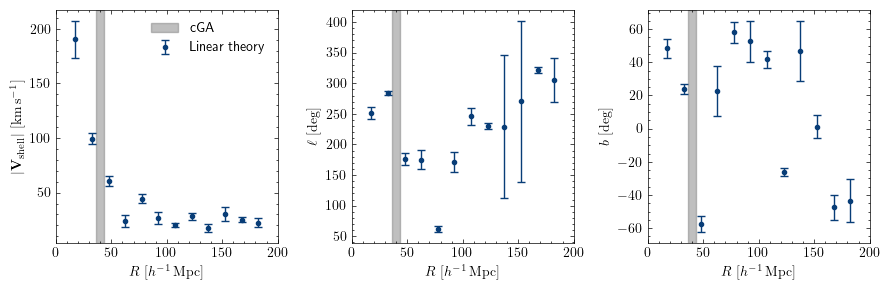

In [5]:
fig, axes = plot_observer_velocity_shells(data_bins)


display(fig)

In [98]:
f = np.load("/Users/rstiskalek/Downloads/quijote_fiducial_velocity_convergence_PCS_z0.npz")


R = f["radii"]
v_full = f["v_full"]
v_radii = f["v_radii"]


v_full_mag = np.linalg.norm(v_full, axis=-1)


mask = (v_full_mag > 520) & (v_full_mag < 720)

v_full = v_full[mask]
v_radii = v_radii[mask]

v_full_mag = np.linalg.norm(v_full, axis=-1)
v_radii_mag = np.linalg.norm(v_radii, axis=-1)


ylow, ymed, yhigh = np.percentile(v_radii_mag, [16, 50, 84], axis=0)

In [99]:
v_full_mag.mean()

np.float64(609.5275198698229)

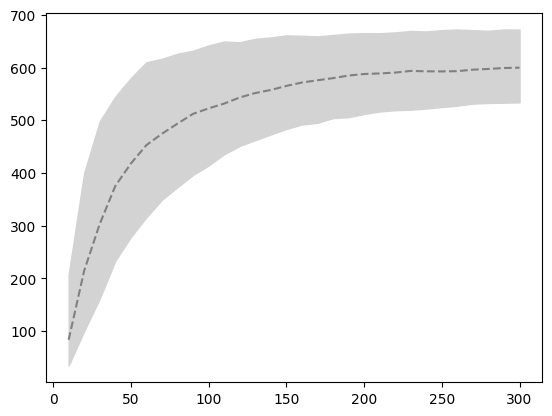

In [102]:
plt.figure()
plt.fill_between(R, ylow, yhigh, color="lightgray", label="Full field (16-84th pct.)")
plt.plot(R, ymed, color="gray", linestyle="--", label="Full field (median)")

plt.show()

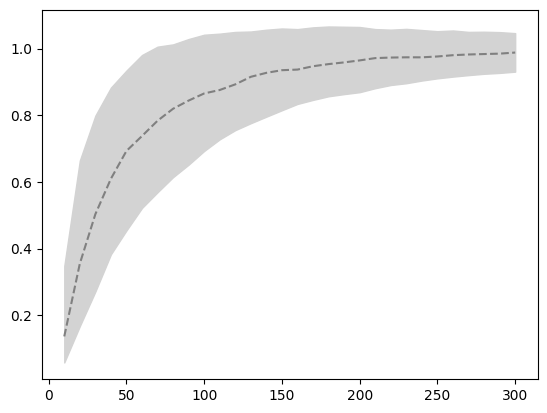

In [103]:
f = v_radii_mag / v_full_mag[:, np.newaxis]

ylow, ymed, yhigh = np.percentile(f, [16, 50, 84], axis=0)


plt.figure()
plt.fill_between(R, ylow, yhigh, color="lightgray", label="Full field (16-84th pct.)")
plt.plot(R, ymed, color="gray", linestyle="--", label="Full field (median)")

plt.show()

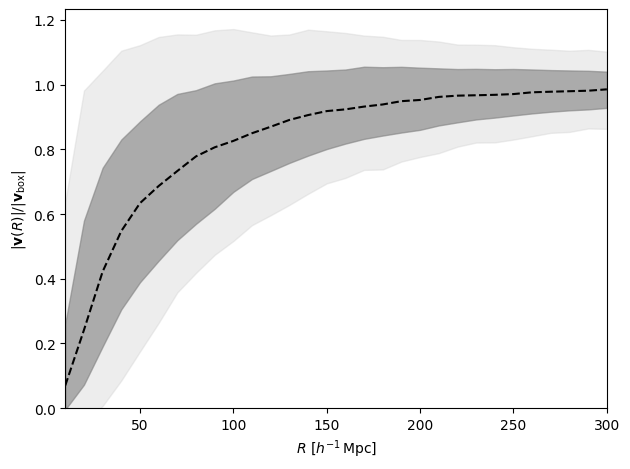

In [104]:
f = np.sum(v_radii * v_full[:, np.newaxis, :], axis=-1) / np.sum(v_full * v_full, axis=-1)[:, np.newaxis]
# f = v_radii_mag / v_full_mag[:, np.newaxis]


ylow2, _, yhigh2 = np.percentile(f, [2.5, 50, 97.5], axis=0)
ylow1, ymed, yhigh1 = np.percentile(f, [16, 50, 84], axis=0)

plt.figure()

# 2σ band (lighter)
plt.fill_between(
    R,
    ylow2,
    yhigh2,
    color="lightgray",
    alpha=0.4,
    label="Full field (2σ)"
)

# 1σ band
plt.fill_between(
    R,
    ylow1,
    yhigh1,
    color="gray",
    alpha=0.6,
    label="Full field (1σ)"
)

# Median
plt.plot(
    R,
    ymed,
    color="black",
    linestyle="--",
    label="Full field (median)"
)

plt.xlabel(r"$R~[h^{-1}\,\mathrm{Mpc}]$")
# plt.ylabel(r"$(\mathbf{v}(R) \cdot \mathbf{v}_{\rm box}) / |\mathbf{v}_{\rm box}|^2$")
plt.ylabel(r"$|\mathbf{v}(R)| / |\mathbf{v}_{\rm box}|$")
plt.ylim(0)
plt.xlim(R.min(), R.max())
plt.tight_layout()
plt.savefig("/Users/rstiskalek/Downloads/velocity_convergence_vs_radius.png", dpi=300)
plt.show()

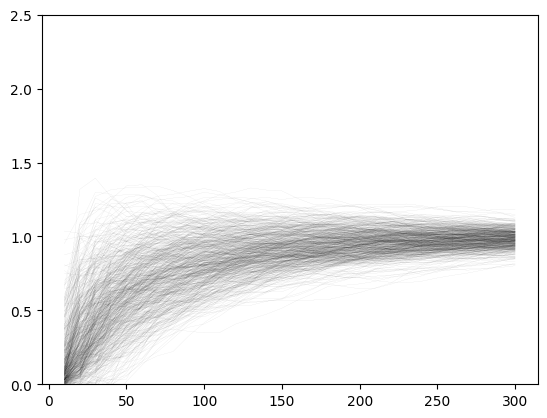

In [106]:
plt.figure()


for i in range(600):
    plt.plot(R, f[i], lw=0.02, c="k")


plt.ylim(0, 2.5)
plt.show()

In [107]:
f = np.sum(v_radii * v_full[:, np.newaxis, :], axis=-1) / np.sum(v_full * v_full, axis=-1)[:, np.newaxis]

f.shape

(631, 30)

In [108]:
def first_crossing_radius(x, R, threshold=0.95):
    """
    Parameters
    ----------
    x : array, shape (nsamp, nR)
        Values as a function of radius.
    R : array, shape (nR,)
        Radial coordinates (monotonic increasing).
    threshold : float

    Returns
    -------
    R_cross : array, shape (nsamp,)
        Interpolated radius of first crossing.
        NaN if the threshold is never crossed.
    """
    nsamp, nR = x.shape

    above = x >= threshold
    has_cross = above.any(axis=1)

    # index of first True along R
    idx = np.argmax(above, axis=1)

    # handle samples with no crossing
    idx0 = idx - 1
    idx0 = np.clip(idx0, 0, nR - 1)

    x0 = x[np.arange(nsamp), idx0]
    x1 = x[np.arange(nsamp), idx]
    R0 = R[idx0]
    R1 = R[idx]

    # linear interpolation
    t = (threshold - x0) / (x1 - x0)
    R_cross = R0 + t * (R1 - R0)

    R_cross[~has_cross] = np.nan
    return R_cross

In [109]:
rcross = first_crossing_radius(f, R, threshold=0.999)

rcross = rcross[np.isfinite(rcross)]

rcross.shape

/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_65643/2183209161.py:35: RuntimeWarning: divide by zero encountered in divide
  t = (threshold - x0) / (x1 - x0)
/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_65643/2183209161.py:36: RuntimeWarning: invalid value encountered in multiply
  R_cross = R0 + t * (R1 - R0)


(390,)

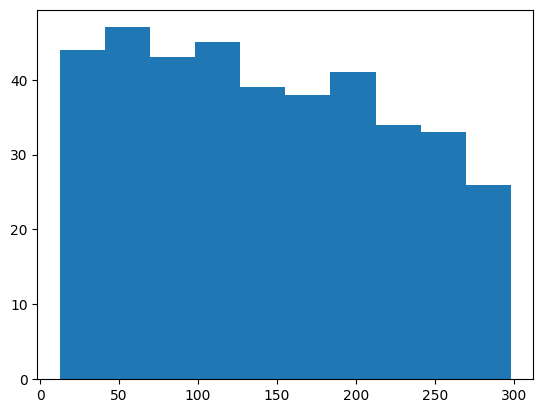

In [110]:
plt.figure()
plt.hist(rcross, bins="auto")
plt.show()

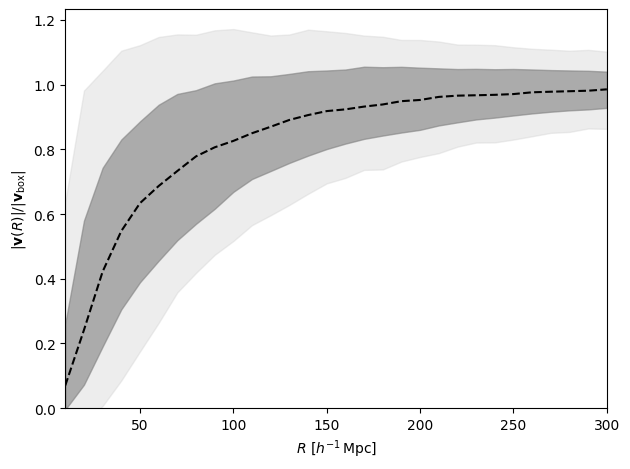

/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_65643/3671617062.py:92: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 180)


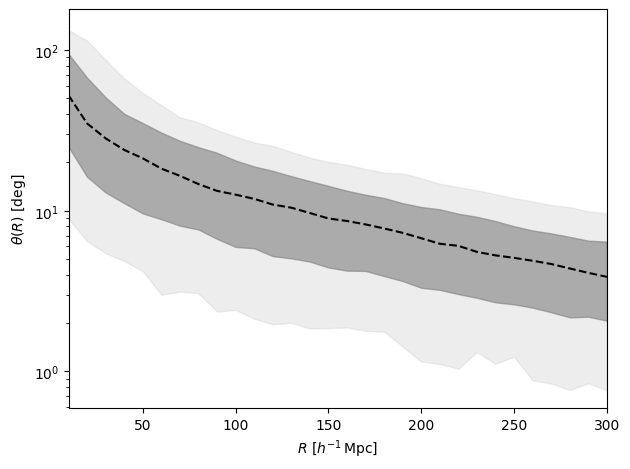

In [115]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Projections and norms
# ------------------------------------------------------------------

# parallel / amplitude-like quantity
f = (
    np.sum(v_radii * v_full[:, None, :], axis=-1)
    / np.sum(v_full * v_full, axis=-1)[:, None]
)

# magnitudes
vR_mag = np.linalg.norm(v_radii, axis=-1)      # (nsamp, nR)
vbox_mag = np.linalg.norm(v_full, axis=-1)     # (nsamp,)

# angular alignment
cos_theta = (
    np.sum(v_radii * v_full[:, None, :], axis=-1)
    / (vR_mag * vbox_mag[:, None])
)


# ------------------------------------------------------------------
# Percentiles
# ------------------------------------------------------------------

# amplitude / projection
f_low2, _, f_high2 = np.percentile(f, [2.5, 50, 97.5], axis=0)
f_low1, f_med, f_high1 = np.percentile(f, [16, 50, 84], axis=0)

# angular alignment
ct_low2, _, ct_high2 = np.percentile(cos_theta, [2.5, 50, 97.5], axis=0)
ct_low1, ct_med, ct_high1 = np.percentile(cos_theta, [16, 50, 84], axis=0)


# ------------------------------------------------------------------
# Plot: amplitude / projection
# ------------------------------------------------------------------

plt.figure()

plt.fill_between(R, f_low2, f_high2, color="lightgray", alpha=0.4)
plt.fill_between(R, f_low1, f_high1, color="gray", alpha=0.6)
plt.plot(R, f_med, color="black", linestyle="--")


# plt.yscale("log")
plt.xlabel(r"$R~[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$|\mathbf{v}(R)| / |\mathbf{v}_{\rm box}|$")
plt.ylim(0)
plt.xlim(R.min(), R.max())
plt.tight_layout()

plt.savefig(
    "/Users/rstiskalek/Downloads/velocity_convergence_vs_radius.png",
    dpi=300
)
plt.show()


# ------------------------------------------------------------------
# Angular misalignment in degrees
# ------------------------------------------------------------------

# numerical safety
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta_deg = np.degrees(np.arccos(cos_theta))

# percentiles
th_low2, _, th_high2 = np.percentile(theta_deg, [2.5, 50, 97.5], axis=0)
th_low1, th_med, th_high1 = np.percentile(theta_deg, [16, 50, 84], axis=0)


# ------------------------------------------------------------------
# Plot: angular misalignment
# ------------------------------------------------------------------

plt.figure()

plt.fill_between(R, th_low2, th_high2, color="lightgray", alpha=0.4)
plt.fill_between(R, th_low1, th_high1, color="gray", alpha=0.6)
plt.plot(R, th_med, color="black", linestyle="--")


plt.yscale("log")
plt.xlabel(r"$R~[h^{-1}\,\mathrm{Mpc}]$")
plt.ylabel(r"$\theta(R)~[\mathrm{deg}]$")
plt.ylim(0, 180)
plt.xlim(R.min(), R.max())
plt.tight_layout()

plt.savefig(
    "/Users/rstiskalek/Downloads/velocity_alignment_angle_vs_radius.png",
    dpi=300
)
plt.show()

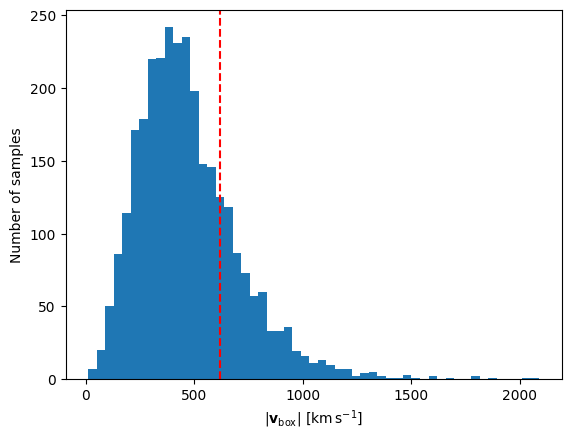

In [87]:
plt.figure()
plt.hist(v_full_mag, bins="auto")
plt.axvline(620, color="red", linestyle="--", label="CMB–LG dipole")
plt.xlabel(r"$|\mathbf{v}_{\rm box}|~[\mathrm{km\,s^{-1}}]$")
plt.ylabel("Number of samples")
plt.show()
